In [10]:
import math
# Import libraries
import os
import sys
import git
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from dask.array import arctan
from pandas.core.methods.selectn import DataFrame

# Checking Python Version
print(f"Running on Python v{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")

# Setting Random Seed
seed = 27
np.random.seed(seed)

Running on Python v3.13.5


In [21]:
# Set the filepath for the dataset
filename_original = "Sp26_HACKATHON_Data_Shared-with-Students (1).csv"
filename_cleaned = "Hackathon_Datasheet_Cleaned.csv"
#filepath = f"../{filename}.csv"

# Load the dataset, raise error if file is not found
try:
    data = pd.read_csv(filepath_or_buffer = filename_original)
    data_cleaned = pd.read_csv(filepath_or_buffer = filename_cleaned, index_col = 0)
except FileNotFoundError:
    print(f"Error: file not found at {filename_original}")
    print(f"Error: file not found at {filename_cleaned}")
except Exception as error:
    print(f"An error occurred: {error}")

# Display data
display(data)
display(data_cleaned)

,ElementA,ElementB,Afrac,Bfrac,Method,Temperature,Activation,Isotope,doi,CrystalStruct,...,MaxOx_B,MaxOx_C,MaxOx_std,MaxOx_max,MaxOx_min,MaxOx_range,MaxOx_mode,SpecificHeatA,SpecificHeatB,SpecificHeat
0,Co,Pd,3.22000,96.780000,Electrochemical double-cell,273-353,0.244493,Hydrogen,https://doi.org/10.1016/b978-0-08-034813-1.500...,fcc,...,3,3.000000,4.440000e-16,3,0,0,3,4.730,9.42,9.268982
1,Fe,Ni,85.00000,15.000000,Build-up,300-363,0.258000,Hydrogen,https://doi.org/10.2320/matertrans1960.24.49,bcc,...,3,3.000000,0.000000e+00,3,0,0,3,4.980,7.02,5.286000
2,Fe,Pd,20.16000,79.840000,Electrochemical double-cell,273-350,0.460485,Hydrogen,https://doi.org/10.1016/b978-0-08-034813-1.500...,fcc,...,3,3.000000,0.000000e+00,3,0,0,3,4.980,9.42,8.524896
3,Mn,Pd,5.10000,94.900000,Electrochemical double-cell,273-361,0.282012,Hydrogen,https://doi.org/10.1016/b978-0-08-034813-1.500...,fcc,...,3,3.204000,3.870000e-01,7,0,4,3,9.200,9.42,9.408780
4,Nb,Ti,29.69174,70.308256,Grosky effect,333.15-573.15,0.132000,Hydrogen,https://doi.org/10.1016/j.jallcom.2006.07.124,bcc,...,4,4.296917,4.180000e-01,5,1,1,4,7.790,1.47,3.346518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Ti,Al,12.00000,88.000000,Gas absorption,923-1298,0.572000,Hydrogen,https://doi.org/10.1039/ft9969200483,hcp,...,3,3.120000,2.110000e-01,4,1,1,3,1.470,1.35,1.364400
71,Ti,V,5.00000,95.000000,Absorption through cylinders,278-500,0.144000,Hydrogen,https://doi.org/10.31274/rtd-180816-5362,bcc,...,5,4.950000,9.500000e-02,4,0,1,5,1.470,9.26,8.870500
72,Ti,V,70.00000,30.000000,Radial concentration,500-1000,0.204000,Hydrogen,https://doi.org/10.4028/www.scientific.net/ddf...,bcc,...,5,4.300000,4.200000e-01,4,0,1,4,1.470,9.26,3.807000
73,Ag,Pd,50.00000,50.000000,Time-lag permeability,523.15-913.15,0.344000,Hydrogen,https://doi.org/10.1021/j100698a005,fcc,...,3,2.000000,1.000000e+00,1,1,2,2,0.646,9.42,5.033000


,ElementA,ElementB,Afrac,Bfrac,Method,Temperature,Isotope,CrystalStruct,E_totalC,lattice_aC,...,Chcp,MinOx_A,MinOx_B,MinOx_C,MaxOx_A,MaxOx_B,MaxOx_C,SpecificHeatA,SpecificHeatB,SpecificHeat
0,27,46,3.22000,96.780000,1,313.00,1,1,-5.197849,3.957381,...,0.032200,2,2,2.000000,3,3,3.000000,4.730,9.42,9.268982
1,26,28,85.00000,15.000000,2,331.50,1,0,-7.827890,2.818550,...,0.000000,2,2,2.000000,3,3,3.000000,4.980,7.02,5.286000
2,26,46,20.16000,79.840000,1,311.50,1,1,-5.753437,3.865958,...,0.000000,2,2,2.000000,3,3,3.000000,4.980,9.42,8.524896
3,25,46,5.10000,94.900000,1,317.00,1,1,-5.330130,3.948030,...,0.000000,2,2,2.000000,7,3,3.204000,9.200,9.42,9.408780
4,41,22,29.69174,70.308256,3,453.15,1,0,-9.349913,3.297950,...,0.703083,3,2,2.296917,5,4,4.296917,7.790,1.47,3.346518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,22,13,12.00000,88.000000,12,1110.50,1,2,-7.310136,2.921920,...,0.120000,2,3,2.880000,4,3,3.120000,1.470,1.35,1.364400
71,22,23,5.00000,95.000000,4,389.00,1,0,-8.900050,3.004450,...,0.050000,2,2,2.000000,4,5,4.950000,1.470,9.26,8.870500
72,22,23,70.00000,30.000000,5,750.00,1,0,-8.079100,3.166300,...,0.700000,2,2,2.000000,4,5,4.300000,1.470,9.26,3.807000
73,47,46,50.00000,50.000000,9,718.15,1,1,-3.932800,4.063500,...,0.000000,1,2,1.500000,1,3,2.000000,0.646,9.42,5.033000


In [22]:
data_cleaned.insert(loc = 6, column = "Activation", value = data["Activation"])

display(data_cleaned.head())

,ElementA,ElementB,Afrac,Bfrac,Method,Temperature,Activation,Isotope,CrystalStruct,E_totalC,...,Chcp,MinOx_A,MinOx_B,MinOx_C,MaxOx_A,MaxOx_B,MaxOx_C,SpecificHeatA,SpecificHeatB,SpecificHeat
0,27,46,3.22000,96.780000,1,313.00,0.244493,1,1,-5.197849,...,0.032200,2,2,2.000000,3,3,3.000000,4.73,9.42,9.268982
1,26,28,85.00000,15.000000,2,331.50,0.258000,1,0,-7.827890,...,0.000000,2,2,2.000000,3,3,3.000000,4.98,7.02,5.286000
2,26,46,20.16000,79.840000,1,311.50,0.460485,1,1,-5.753437,...,0.000000,2,2,2.000000,3,3,3.000000,4.98,9.42,8.524896
3,25,46,5.10000,94.900000,1,317.00,0.282012,1,1,-5.330130,...,0.000000,2,2,2.000000,7,3,3.204000,9.20,9.42,9.408780
4,41,22,29.69174,70.308256,3,453.15,0.132000,1,0,-9.349913,...,0.703083,3,2,2.296917,5,4,4.296917,7.79,1.47,3.346518


# Dataset Clean-up:

In [14]:
# Set the filepath for the dataset
filename = "output.csv"
#filepath = f"../{filename}.csv"

# Load the dataset, raise error if file is not found
try:
    data = pd.read_csv(filepath_or_buffer = filename)
except FileNotFoundError:
    print(f"Error: file not found at {filename}")
except Exception as error:
    print(f"An error occurred: {error}")

# Display data
data.head(10)

,ElementA,ElementB,Afrac,Bfrac,Method,Temperature,Activation,Isotope,CrystalStruct,E_totalC,...,MaxOx_B,MaxOx_C,MaxOx_std,MaxOx_max,MaxOx_min,MaxOx_range,MaxOx_mode,SpecificHeatA,SpecificHeatB,SpecificHeat
0,27,46,3.22000,96.780000,1,313.00,0.244493,1,1,-5.197849,...,3,3.000000,4.440000e-16,3,0,0,3,4.73,9.42,9.268982
1,26,28,85.00000,15.000000,2,331.50,0.258000,1,0,-7.827890,...,3,3.000000,0.000000e+00,3,0,0,3,4.98,7.02,5.286000
2,26,46,20.16000,79.840000,1,311.50,0.460485,1,1,-5.753437,...,3,3.000000,0.000000e+00,3,0,0,3,4.98,9.42,8.524896
3,25,46,5.10000,94.900000,1,317.00,0.282012,1,1,-5.330130,...,3,3.204000,3.870000e-01,7,0,4,3,9.20,9.42,9.408780
4,41,22,29.69174,70.308256,3,453.15,0.132000,1,0,-9.349913,...,4,4.296917,4.180000e-01,5,1,1,4,7.79,1.47,3.346518
5,41,23,90.00000,10.000000,4,389.00,0.209500,1,0,-9.938260,...,5,5.000000,0.000000e+00,5,1,0,5,7.79,9.26,7.937000
6,26,28,60.00000,40.000000,2,331.50,0.496000,1,1,-7.068400,...,3,3.000000,0.000000e+00,3,0,0,3,4.98,7.02,5.796000
7,41,23,75.00000,25.000000,4,389.00,0.206000,1,0,-9.775750,...,5,5.000000,0.000000e+00,5,1,0,5,7.79,9.26,8.157500
8,22,23,20.00000,80.000000,4,389.00,0.183000,1,0,-8.710600,...,5,4.800000,3.200000e-01,4,0,1,5,1.47,9.26,7.702000
9,22,23,90.00000,10.000000,5,750.00,0.286000,1,0,-7.826500,...,5,4.100000,1.800000e-01,4,0,1,4,1.47,9.26,2.249000


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Columns: 406 entries, ElementA to SpecificHeat
dtypes: float64(308), int64(95), str(3)
memory usage: 238.0 KB


In [4]:
drop_columns = []
str_columns = []
for header in list(data.keys()):
    if (header.find("min") != -1):
        drop_columns.append(header)
    elif header.find("max") != -1:
        drop_columns.append(header)
    elif header.find("mode") != -1:
        drop_columns.append(header)
    elif header.find("range") != -1:
        drop_columns.append(header)
    elif header.find(".1") != -1:
        drop_columns.append(header)
    elif header.find("std") != -1:
        drop_columns.append(header)
    elif header.find("Activation") != -1:
        drop_columns.append(header)

    if data.dtypes[header] == "str":
        if header == "CZungerPP.r_d":
            #print(header)
            str_columns.append(header)
        #drop_columns.append(header)
    #print(data.dtypes[header])

In [5]:
drop_columns

['Activation',
 'CFirstIonizationEnergy.1',
 'E_total_std',
 'lattice_a_std',
 'lattice_c.a_std',
 'pack.factor_std',
 'radius.of.host_std',
 'atomic.number.of.host_std',
 'valence.electron.of.host_std',
 'ThermExp_std',
 'atomic.mass.of.host_std',
 'Td.Tm_std',
 'Evac_std',
 'φnws_std',
 'Δφ._std',
 'Q1_std',
 'TCA_std',
 'Atomic.Volume_std',
 'Atomic.Weight_std',
 'Boiling.Temp_std',
 'Bulk.Modulus_std',
 'Column_std',
 'Covalent.Radius_std',
 'Density_std',
 'DipolePolarizability_std',
 'ElectronAffinity_std',
 'Electronegativity_std',
 'FirstIonizationEnergy_std',
 'FusionEnthalpy_std',
 'Gsenergy_pa_std',
 'GSestBCClatcnt_std',
 'GSestFCClatcnt_std',
 'Gsmagmom_std',
 'Gsvolume.pa_std',
 'HHlp_std',
 'HHlr_std',
 'HeatCapacityMass_std',
 'HeatCapacityMolar_std',
 'HeatFusion_std',
 'ICSD_std',
 'FirstIonizationEnergy_std.1',
 'IsDBlock_std',
 'IsMetal_std',
 'MeltingT_std',
 'MiracleRadius_std',
 'Nunfilled_std',
 'Nvalence_std',
 'Nfvalence_std',
 'Npunfilled_std',
 'Npvalence_st

In [6]:
t = 0
f = 0
for compare in list(data["CFirstIonizationEnergy.1"] == data["CFirstIonizationEnergy"]):
    if compare == True:
        t = t + 1
    else:
        f = f + 1

print("True:", t)
print("False:", f)

True: 75
False: 0


In [7]:
data_cleaned = data.drop(columns = drop_columns)

data_cleaned.head(10)

,ElementA,ElementB,Afrac,Bfrac,Method,Temperature,Isotope,CrystalStruct,E_totalC,lattice_aC,...,Chcp,MinOx_A,MinOx_B,MinOx_C,MaxOx_A,MaxOx_B,MaxOx_C,SpecificHeatA,SpecificHeatB,SpecificHeat
0,27,46,3.22000,96.780000,1,313.00,1,1,-5.197849,3.957381,...,0.032200,2,2,2.000000,3,3,3.000000,4.73,9.42,9.268982
1,26,28,85.00000,15.000000,2,331.50,1,0,-7.827890,2.818550,...,0.000000,2,2,2.000000,3,3,3.000000,4.98,7.02,5.286000
2,26,46,20.16000,79.840000,1,311.50,1,1,-5.753437,3.865958,...,0.000000,2,2,2.000000,3,3,3.000000,4.98,9.42,8.524896
3,25,46,5.10000,94.900000,1,317.00,1,1,-5.330130,3.948030,...,0.000000,2,2,2.000000,7,3,3.204000,9.20,9.42,9.408780
4,41,22,29.69174,70.308256,3,453.15,1,0,-9.349913,3.297950,...,0.703083,3,2,2.296917,5,4,4.296917,7.79,1.47,3.346518
5,41,23,90.00000,10.000000,4,389.00,1,0,-9.938260,3.289000,...,0.000000,3,2,2.900000,5,5,5.000000,7.79,9.26,7.937000
6,26,28,60.00000,40.000000,2,331.50,1,1,-7.068400,3.474400,...,0.000000,2,2,2.000000,3,3,3.000000,4.98,7.02,5.796000
7,41,23,75.00000,25.000000,4,389.00,1,0,-9.775750,3.239500,...,0.000000,3,2,2.750000,5,5,5.000000,7.79,9.26,8.157500
8,22,23,20.00000,80.000000,4,389.00,1,0,-8.710600,3.041800,...,0.200000,2,2,2.000000,4,5,4.800000,1.47,9.26,7.702000
9,22,23,90.00000,10.000000,5,750.00,1,0,-7.826500,3.216100,...,0.900000,2,2,2.000000,4,5,4.100000,1.47,9.26,2.249000


In [8]:
data_cleaned.to_csv("TESTER.csv")

# Functions:

## Radviz:

In [25]:
def radviz(dataframe: pd.DataFrame, class_num: int, filename: str):
    palette = sns.color_palette("colorblind", n_colors = class_num)
    opacity = 1.0
    color = [(*color, opacity) for color in palette]

    # Adjust figure dimensions
    plt.figure(figsize = (15, 15))
    ax = plt.gca()

    # Plot origin
    plt.plot(
        0, 0,
        marker = "o",
        color = "black",
        markersize = 10,
        zorder = 1
    )

    # Make a point for each feature
    num_features = len(dataframe.columns) - 1

    point_list = []
    for feature in range(num_features):
        point = [
            np.cos(feature * ((2 * np.pi) / num_features)),
            np.sin(feature * ((2 * np.pi) / num_features)),
        ]
        point_list.append(point)

        # Make dashed lines leading to the features
        plt.plot(
            [0, point[0]],
            [0, point[1]],
            linestyle = "--",
            color = "black",
            zorder = 0
        )

    # Create the radviz plot
    pd.plotting.radviz(
        frame = dataframe,
        class_column = dataframe.columns[-1],
        color = color,
        marker = "o",
        s = 120,
        edgecolors = "black",
        zorder = 2
    )

    # Format the legend and axes
    ax.get_legend().set_visible(True)
    ax.legend(fontsize = 16, bbox_to_anchor = (1, 1), ncols = 2, title = "Method", title_fontsize = 14).get_frame().set_edgecolor('black')
    ax.set_axis_off()
    #ax.tick_params(rotation=45)

    # Change the fontsize of the feature labels
    for label, rotation in zip(ax.texts, point_list):
        label.set_fontsize(18)
        angle = np.arctan(rotation[1] / rotation[0])
        angle_degrees = angle * (180 / np.pi)
        label.set_rotation(angle_degrees)

    # Make concentric circles to connect column labels and show distances
    radii = np.arange(0.05, 0.85 + 0.01, 0.1)
    radii = np.append(radii, 1)

    # Circle generating function
    def circles(radius):
        circle = plt.Circle(
            (0, 0),
            radius = radius,
            color = 'black',
            linestyle = '--',
            fill = False,
            zorder = 0
        )
        ax.add_patch(circle)

        return

    # Loop through all radii
    for radius in radii:
        if radius != 1:
            circles(radius)
        else:
            circle = plt.Circle((0, 0), radius = radius, color = 'black', fill = False)
            ax.add_patch(circle)

    # Save the plot as a png file
    # filepath = os.path.join("../results/", f"{filename}_Radviz.png")
    # plt.savefig(filepath, bbox_inches = "tight")
    # plt.show()

    return

# Visualization:

## Radviz:

In [26]:
# Min-Max Normalization
drop_cols = ['Method']
data_radviz = data_cleaned.drop(columns = drop_cols)
normalized   = (data_radviz - data_radviz.min())/(data_radviz.max() - data_radviz.min())
print(f'{normalized.agg(['min', 'max'])}')

     ElementA  ElementB  Afrac  Bfrac  Temperature  Activation  Isotope  \
min       0.0       0.0    0.0    0.0          0.0         0.0      0.0   
max       1.0       1.0    1.0    1.0          1.0         1.0      1.0   

     CrystalStruct  E_totalC  lattice_aC  ...  Chcp  MinOx_A  MinOx_B  \
min            0.0       0.0         0.0  ...   0.0      0.0      0.0   
max            1.0       1.0         1.0  ...   1.0      1.0      1.0   

     MinOx_C  MaxOx_A  MaxOx_B  MaxOx_C  SpecificHeatA  SpecificHeatB  \
min      0.0      0.0      0.0      0.0            0.0            0.0   
max      1.0      1.0      1.0      1.0            1.0            1.0   

     SpecificHeat  
min           0.0  
max           1.0  

[2 rows x 92 columns]


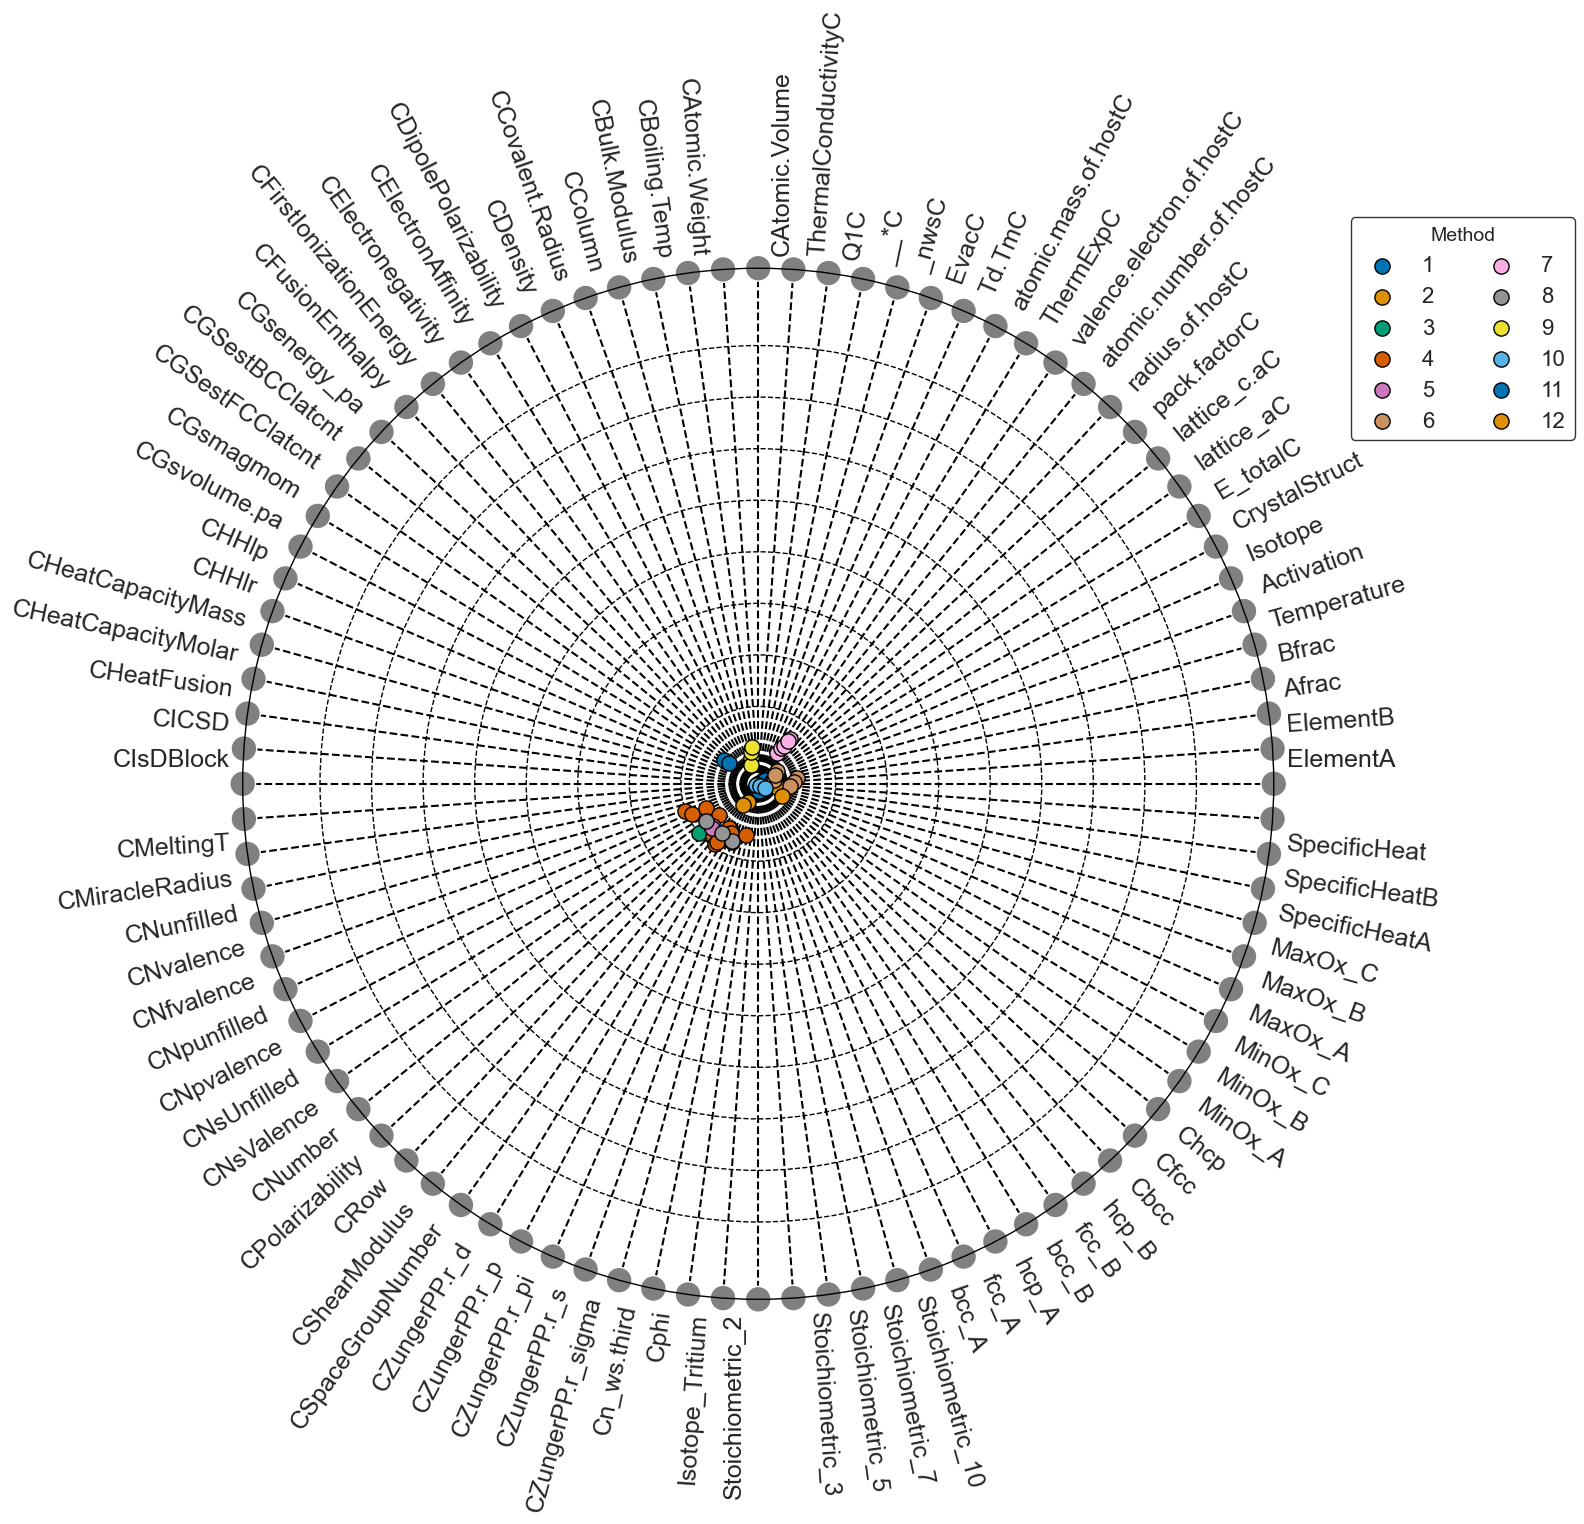

In [27]:
# Normalized dataset should not have materials column and the type column should be at the end
types = data_cleaned["Method"]
uniqueClasses = len(data_cleaned["Method"].unique())

append = pd.concat([normalized, types], axis = 1)
append.head()

# Call Radviz function
radviz(append, class_num = uniqueClasses, filename = "Radviz")

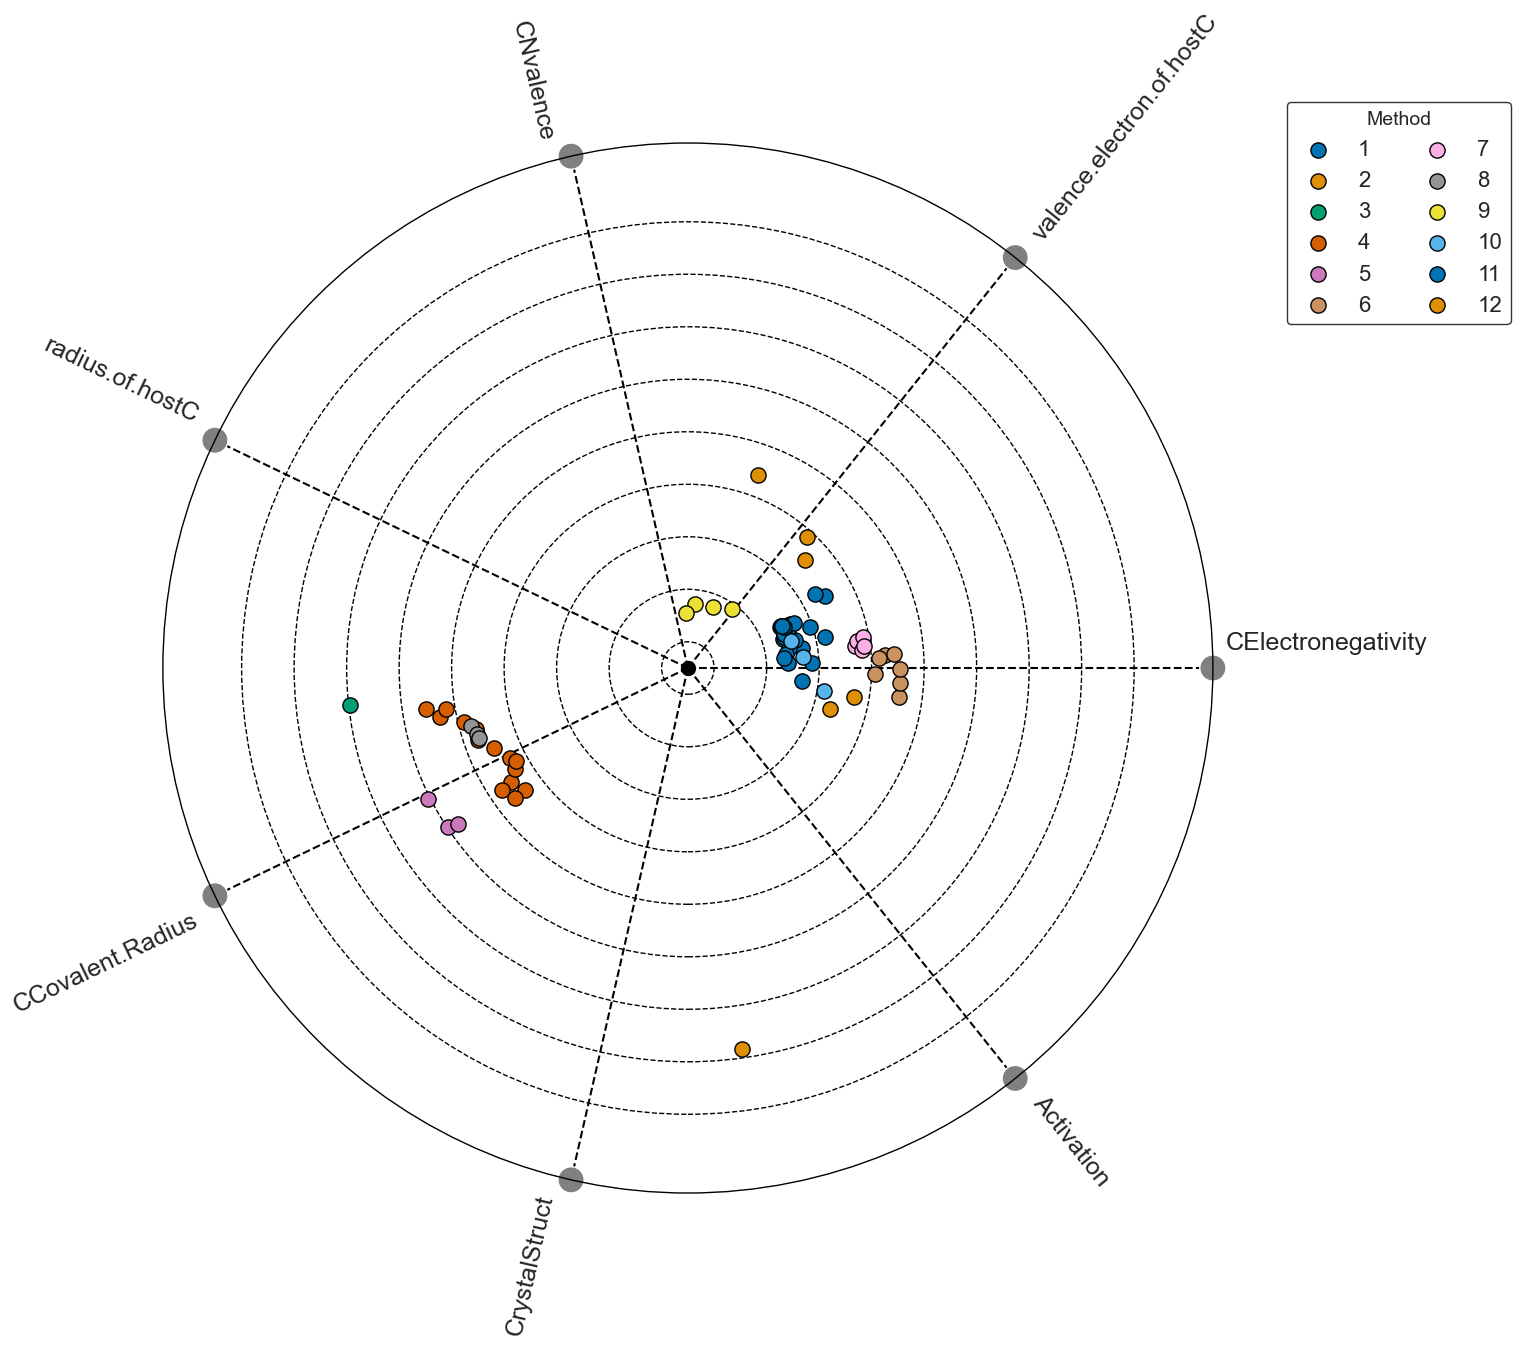

In [65]:
# Attempt @ Hume-Rothery Rules
radviz(append.get(["CElectronegativity", "valence.electron.of.hostC", "CNvalence", "radius.of.hostC", "CCovalent.Radius", "CrystalStruct", "Activation", "Method"]),
                    class_num = uniqueClasses, filename = "Radviz")

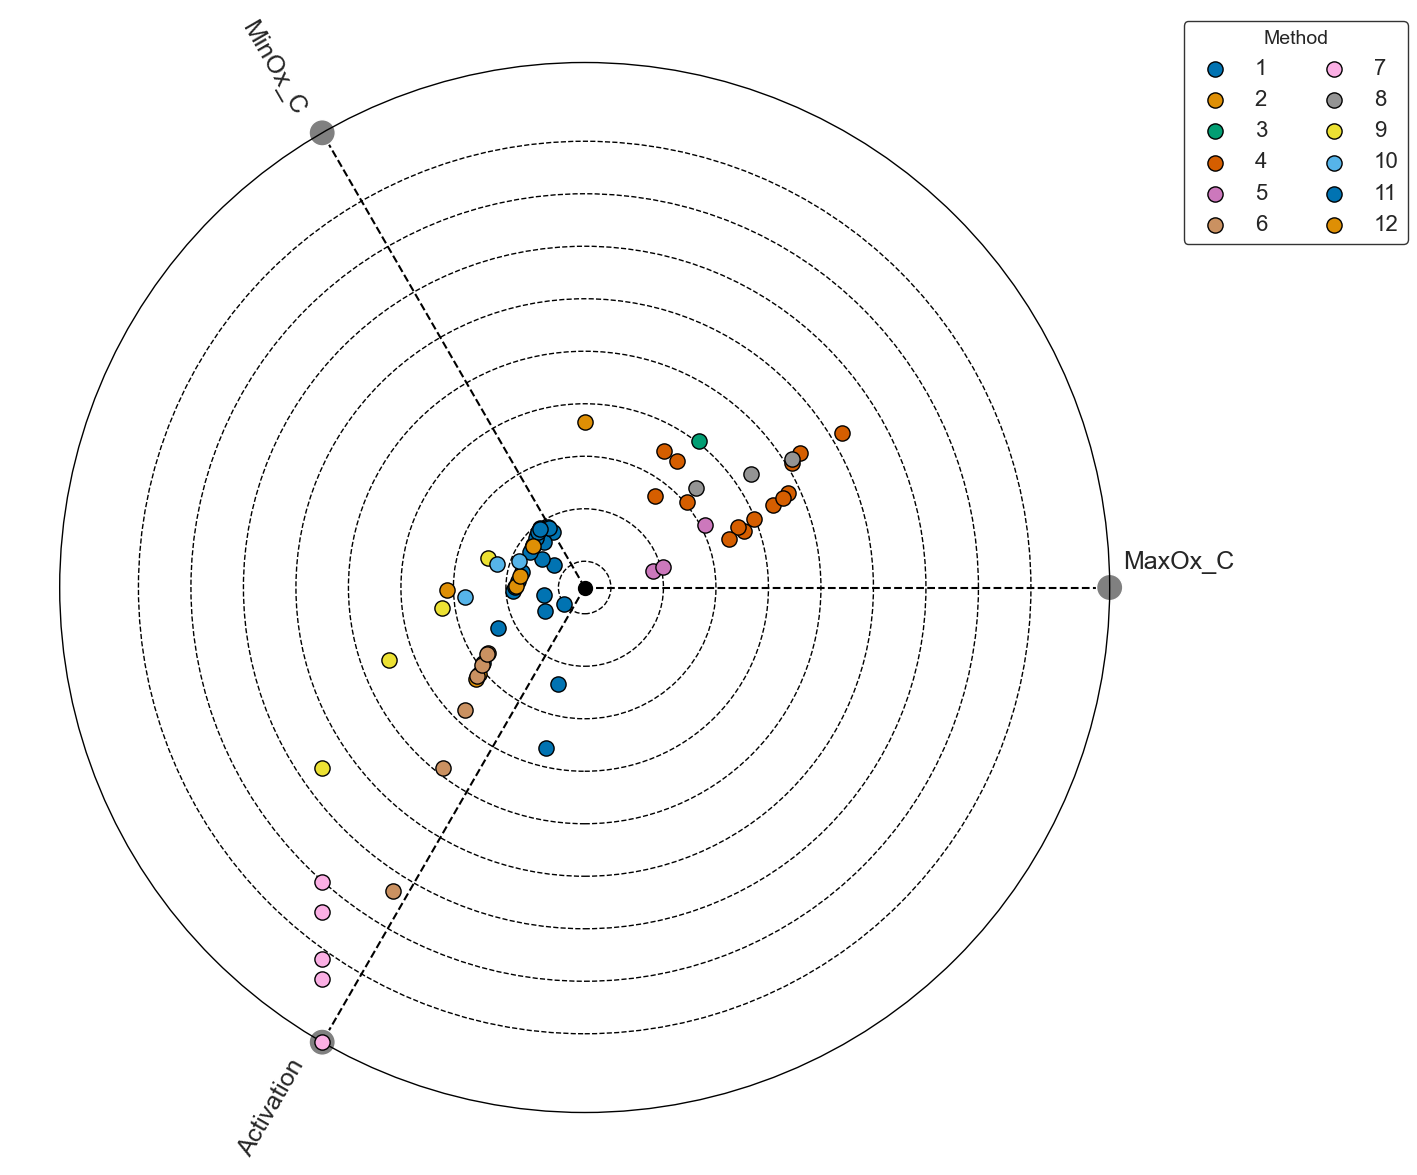

In [64]:
# Based on the Method used to create the resulting crystal system C, how does the oxidation state extrema impact the activation energy?
radviz(append.get(["MaxOx_C","MinOx_C", "Activation", "Method"]),
                    class_num = uniqueClasses, filename = "Radviz")

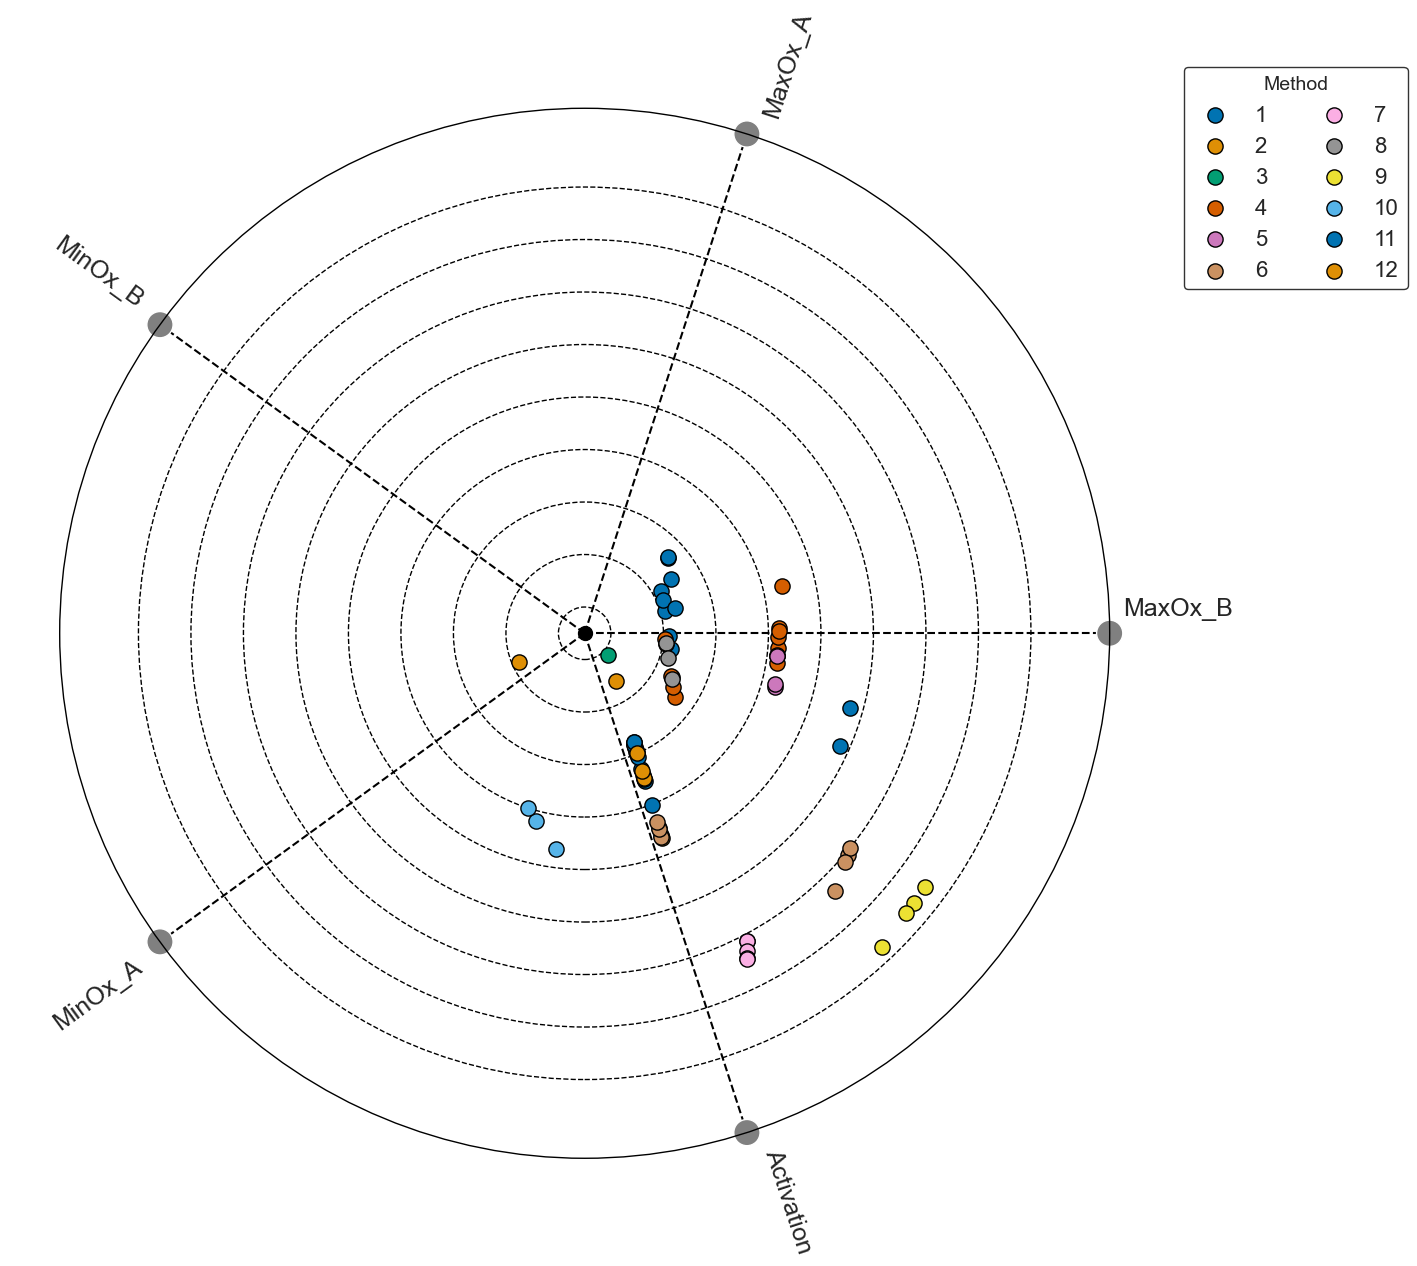

In [62]:
# How does the oxidation state extrema impact of the starting binary alloy impact the activation energy? What methods used on the binary alloy impact the activation energy the most?
radviz(append.get(["MaxOx_B","MaxOx_A",
                   "MinOx_B","MinOx_A", "Activation", "Method"]),
                    class_num = uniqueClasses, filename = "Radviz")

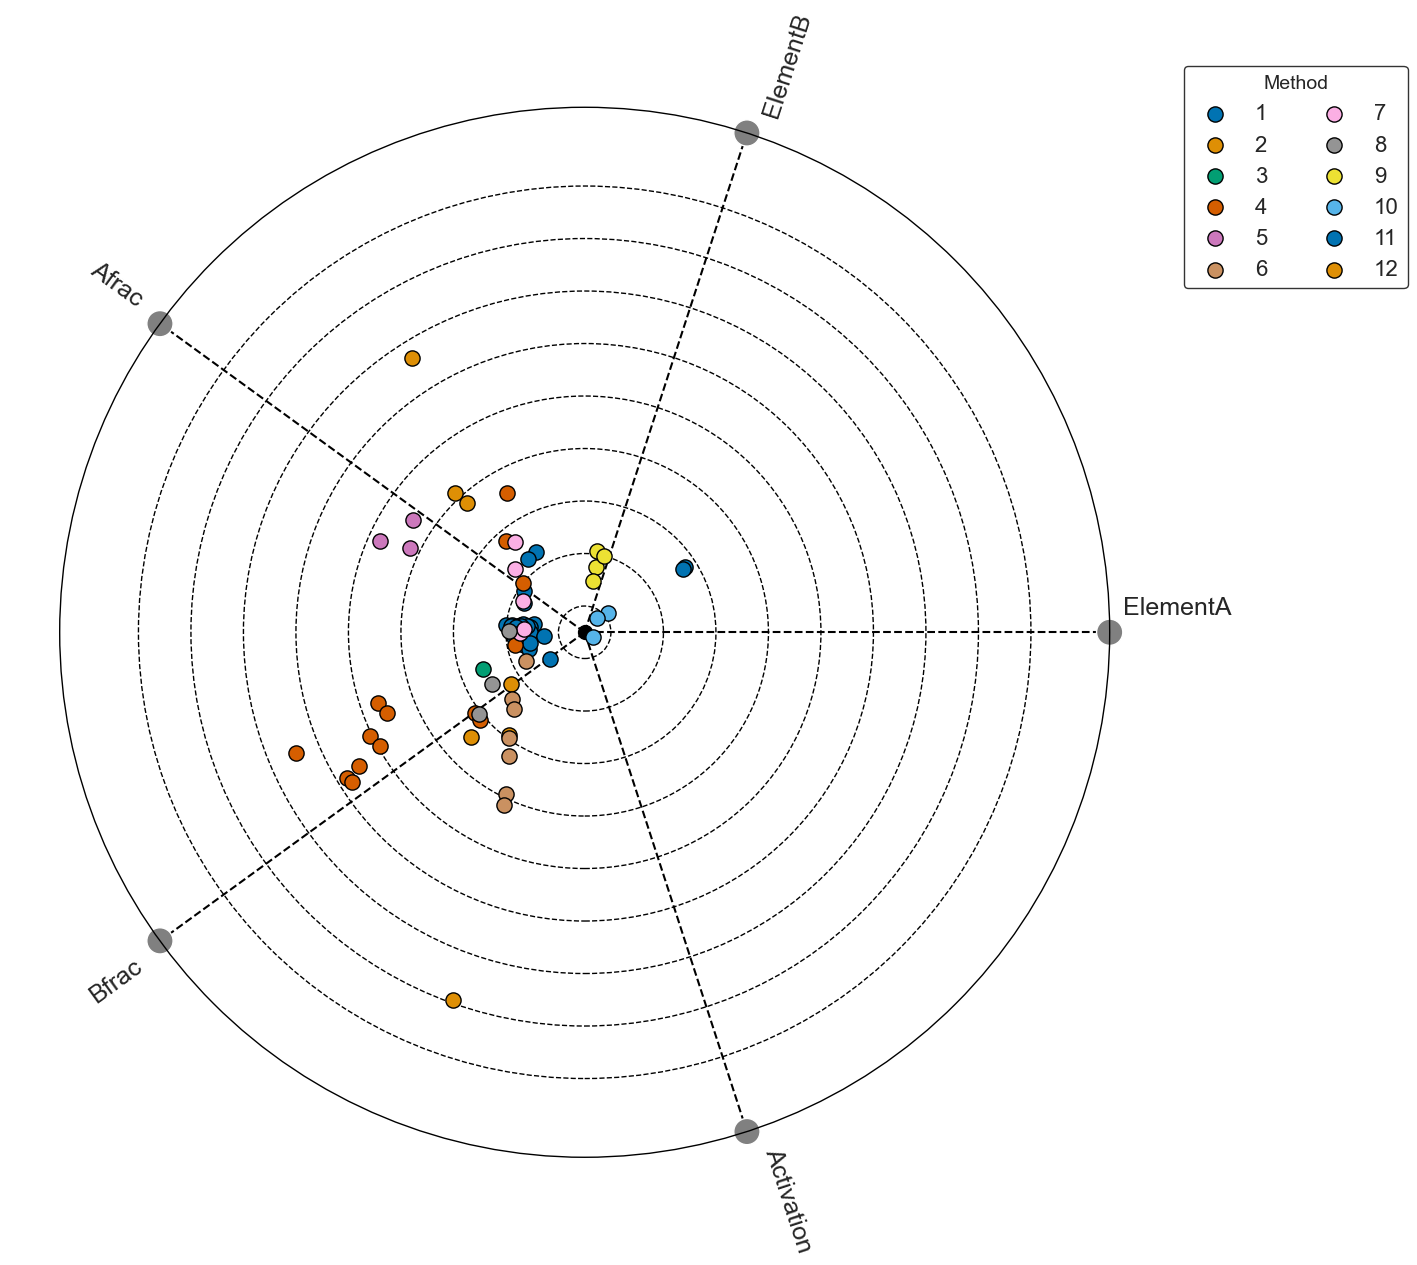

In [46]:
# How does the composition of the starting binary alloy impact the activation energy? Does this impact the method chosen?
radviz(append.get(["ElementA", "ElementB", "Afrac", "Bfrac", "Activation", "Method"]),
                    class_num = uniqueClasses, filename = "Radviz")

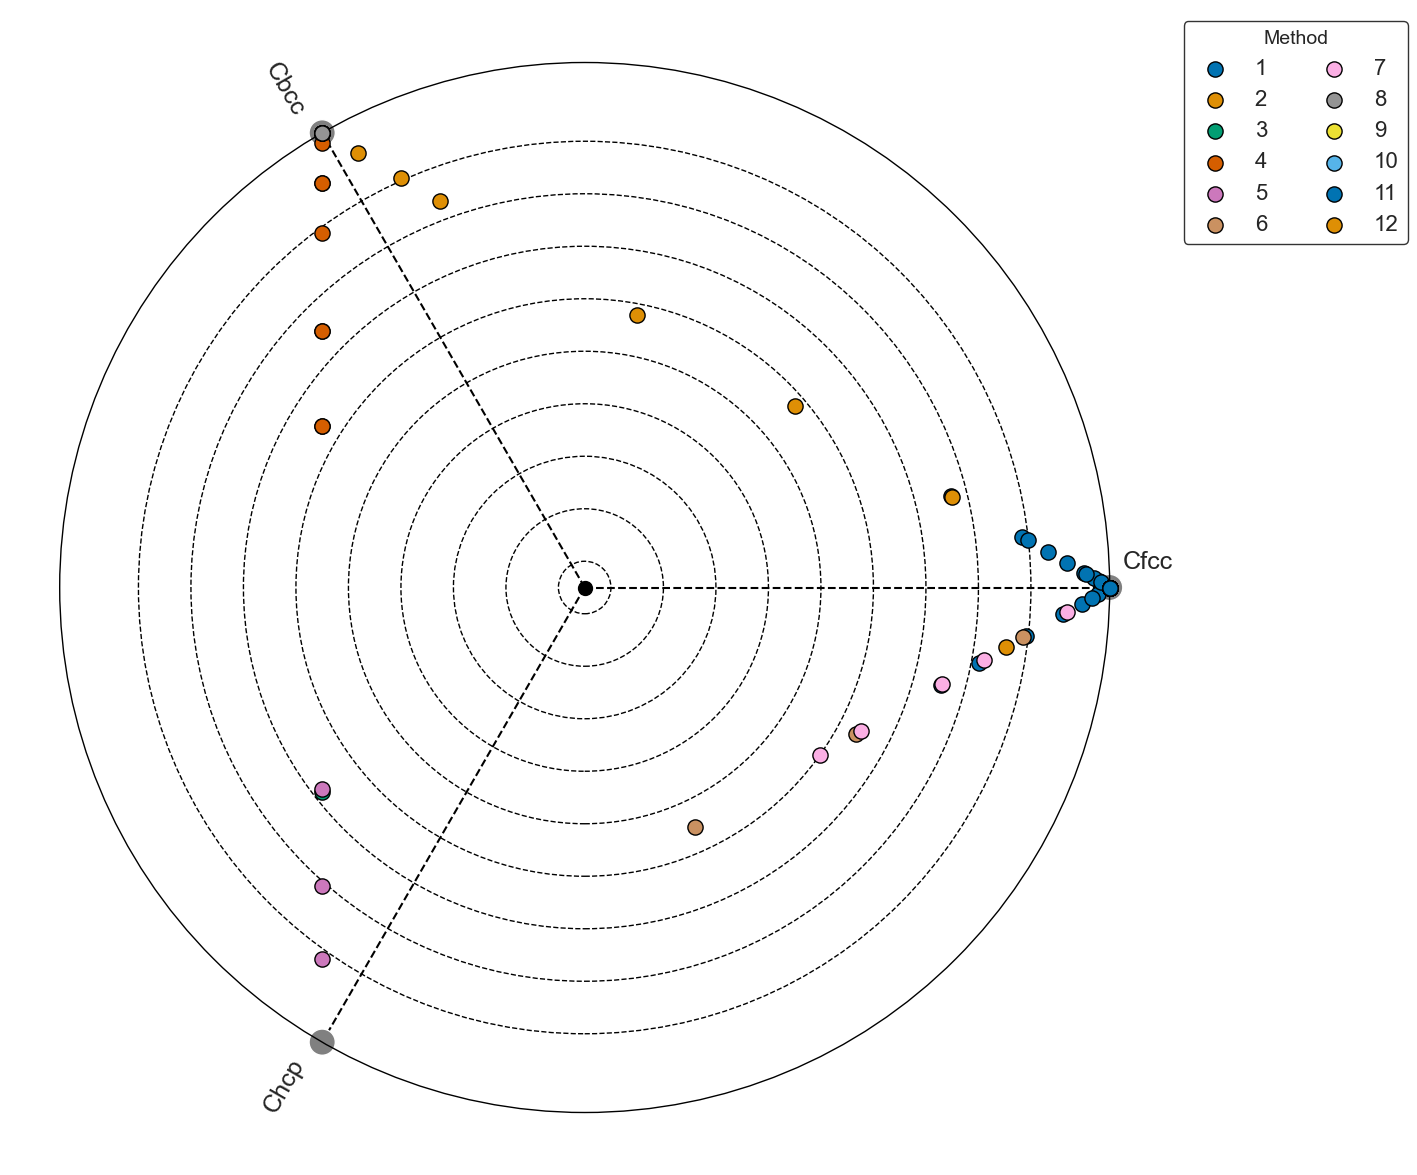

In [56]:
# How does the method used impact the resulting crystal structure?
radviz(append.get(["Cfcc", "Cbcc","Chcp", "Method"]),
                    class_num = uniqueClasses, filename = "Radviz")

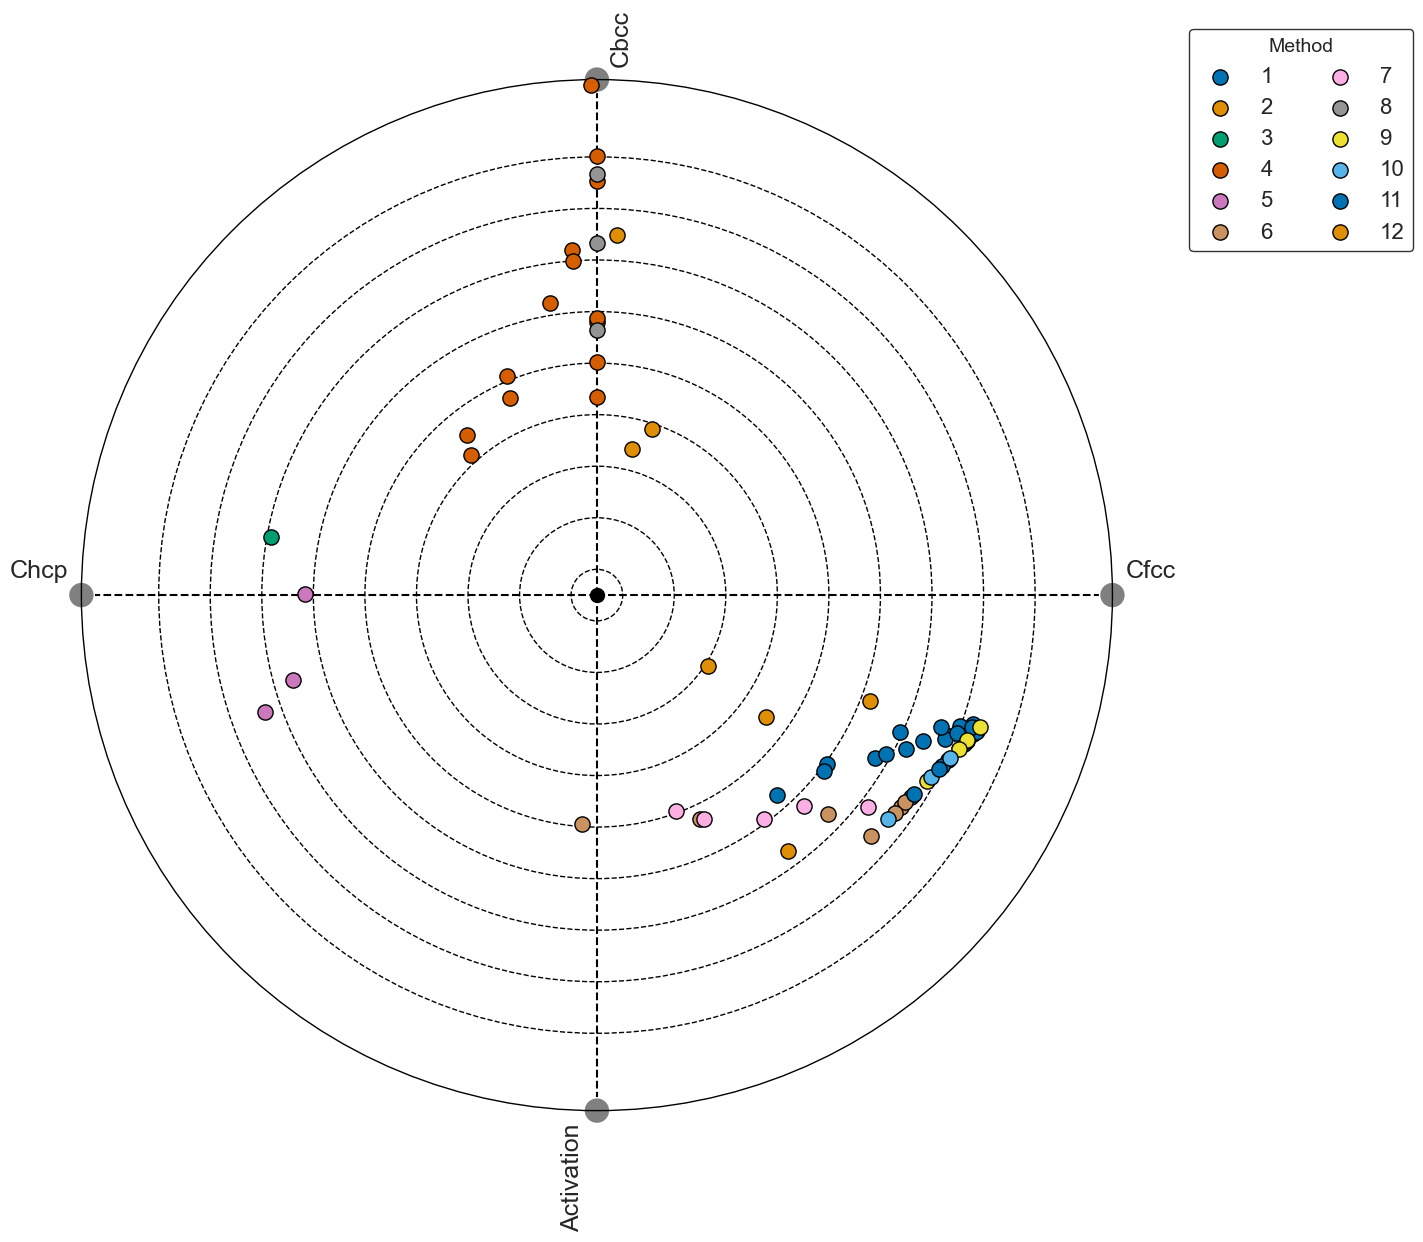

In [59]:
# Based on the Method used to create the resulting crystal structure in system C, how does the crystal structure impact the activation energy?
radviz(append.get(["Cfcc", "Cbcc","Chcp", "Activation", "Method"]),
                    class_num = uniqueClasses, filename = "Radviz")

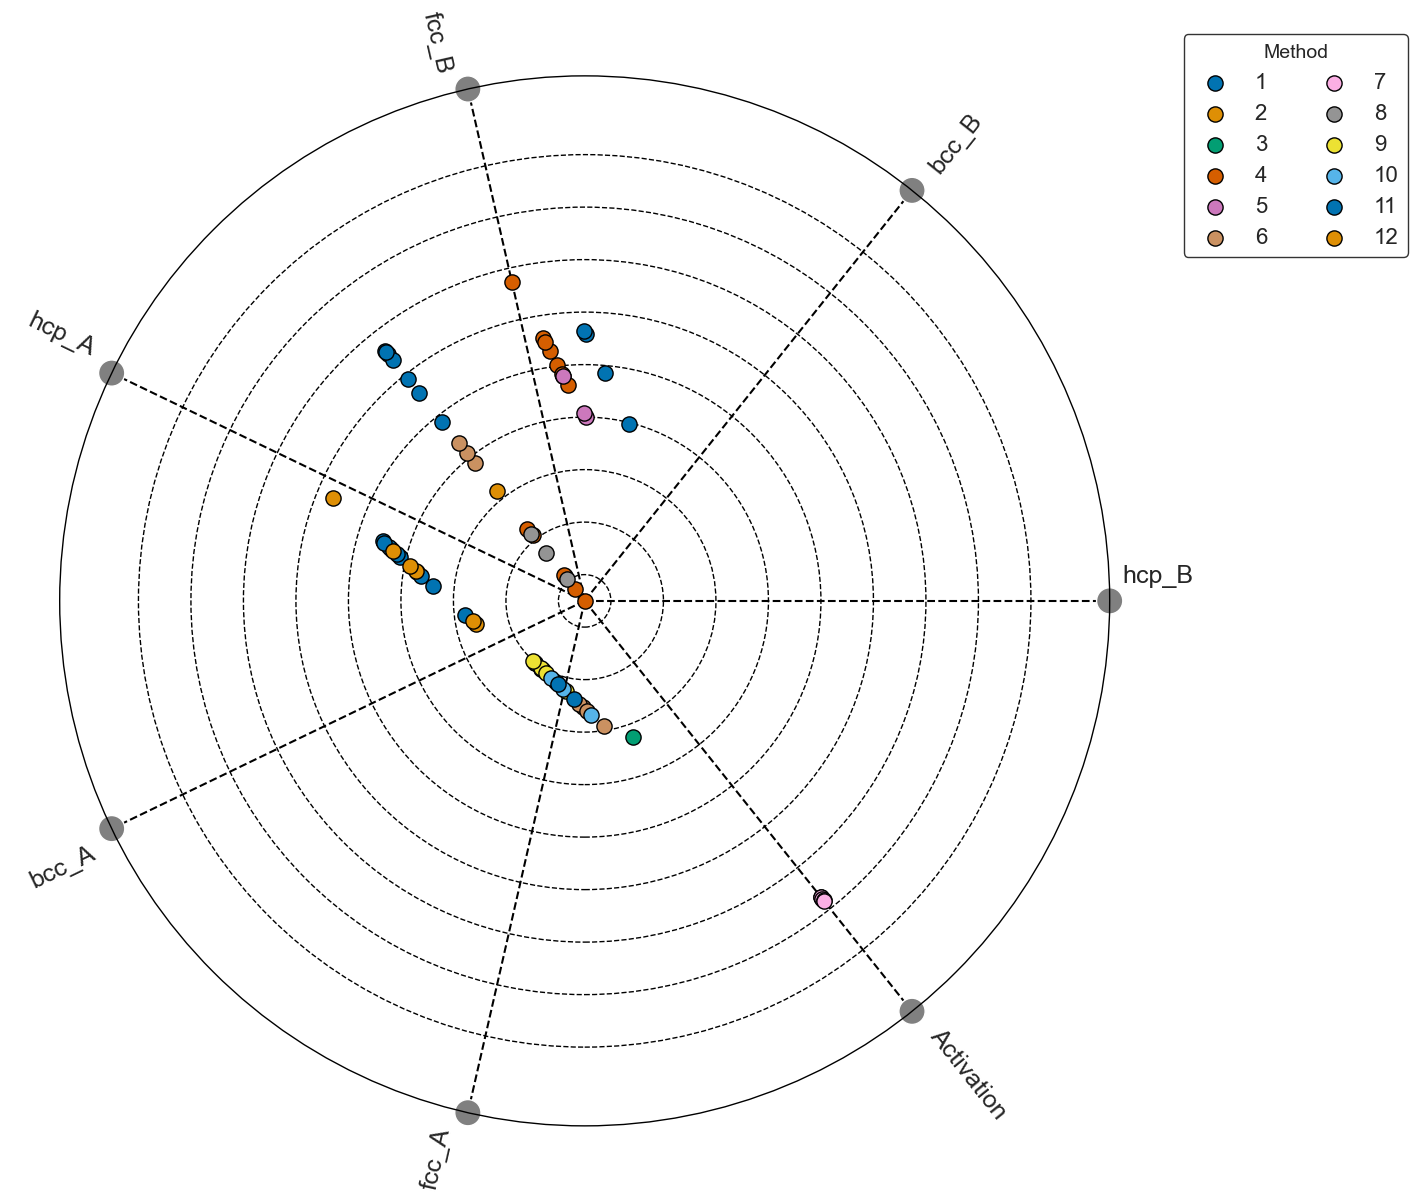

In [58]:
# How does the crystal structure of the starting binary alloy impact the activation energy? Does this determine the method used?
radviz(append.get(["hcp_B", "bcc_B","fcc_B", "hcp_A", "bcc_A", "fcc_A", "Activation", "Method"]),
                    class_num = uniqueClasses, filename = "Radviz")

## Heatmap:

<Axes: title={'center': 'Correlation Matrix'}>

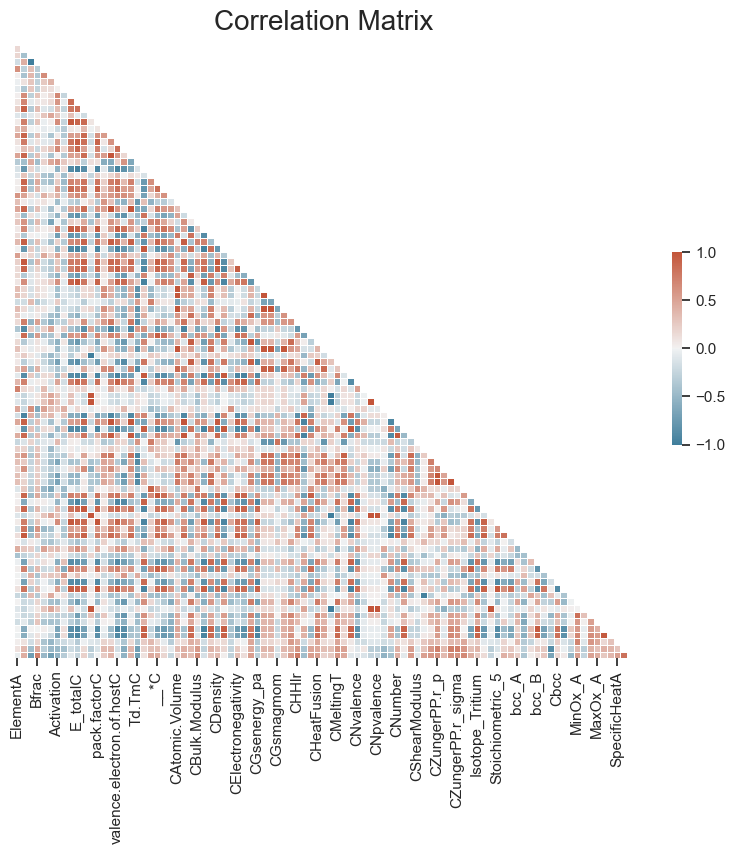

In [30]:
# Source: https://seaborn.pydata.org/examples/many_pairwise_correlations.html

sns.set_theme(style="white")

# Compute the correlation matrix
corr = data_cleaned.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(10, 10))
ax.xaxis.tick_bottom()
ax.set_title("Correlation Matrix", fontsize = 20)

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": 0.25, "location" : "right", "orientation" : "vertical"}, xticklabels=3, yticklabels = False)


## Correlogram:

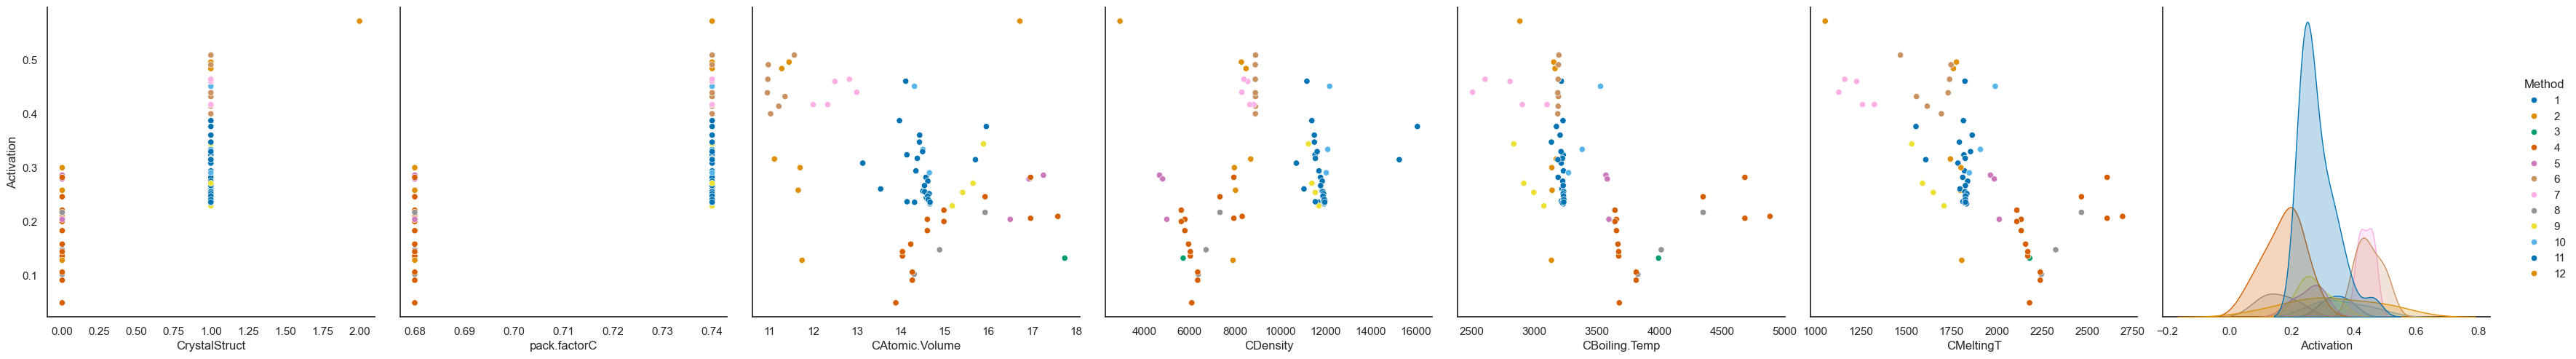

In [31]:
# Source(s): https://python-graph-gallery.com/111-custom-correlogram/
# https://python-graph-gallery.com/110-basic-correlation-matrix-with-seaborn/

palette = sns.color_palette("colorblind", n_colors = len(data_cleaned["Method"].unique()))
opacity = 1.0
color = [(*color, opacity) for color in palette]

a = sns.pairplot(data_cleaned, x_vars = ["CrystalStruct", "pack.factorC", "CAtomic.Volume", "CDensity", "CBoiling.Temp", "CMeltingT", "Activation"], y_vars = ["Activation"], hue = "Method", height = 5, palette = color)

plt.show()

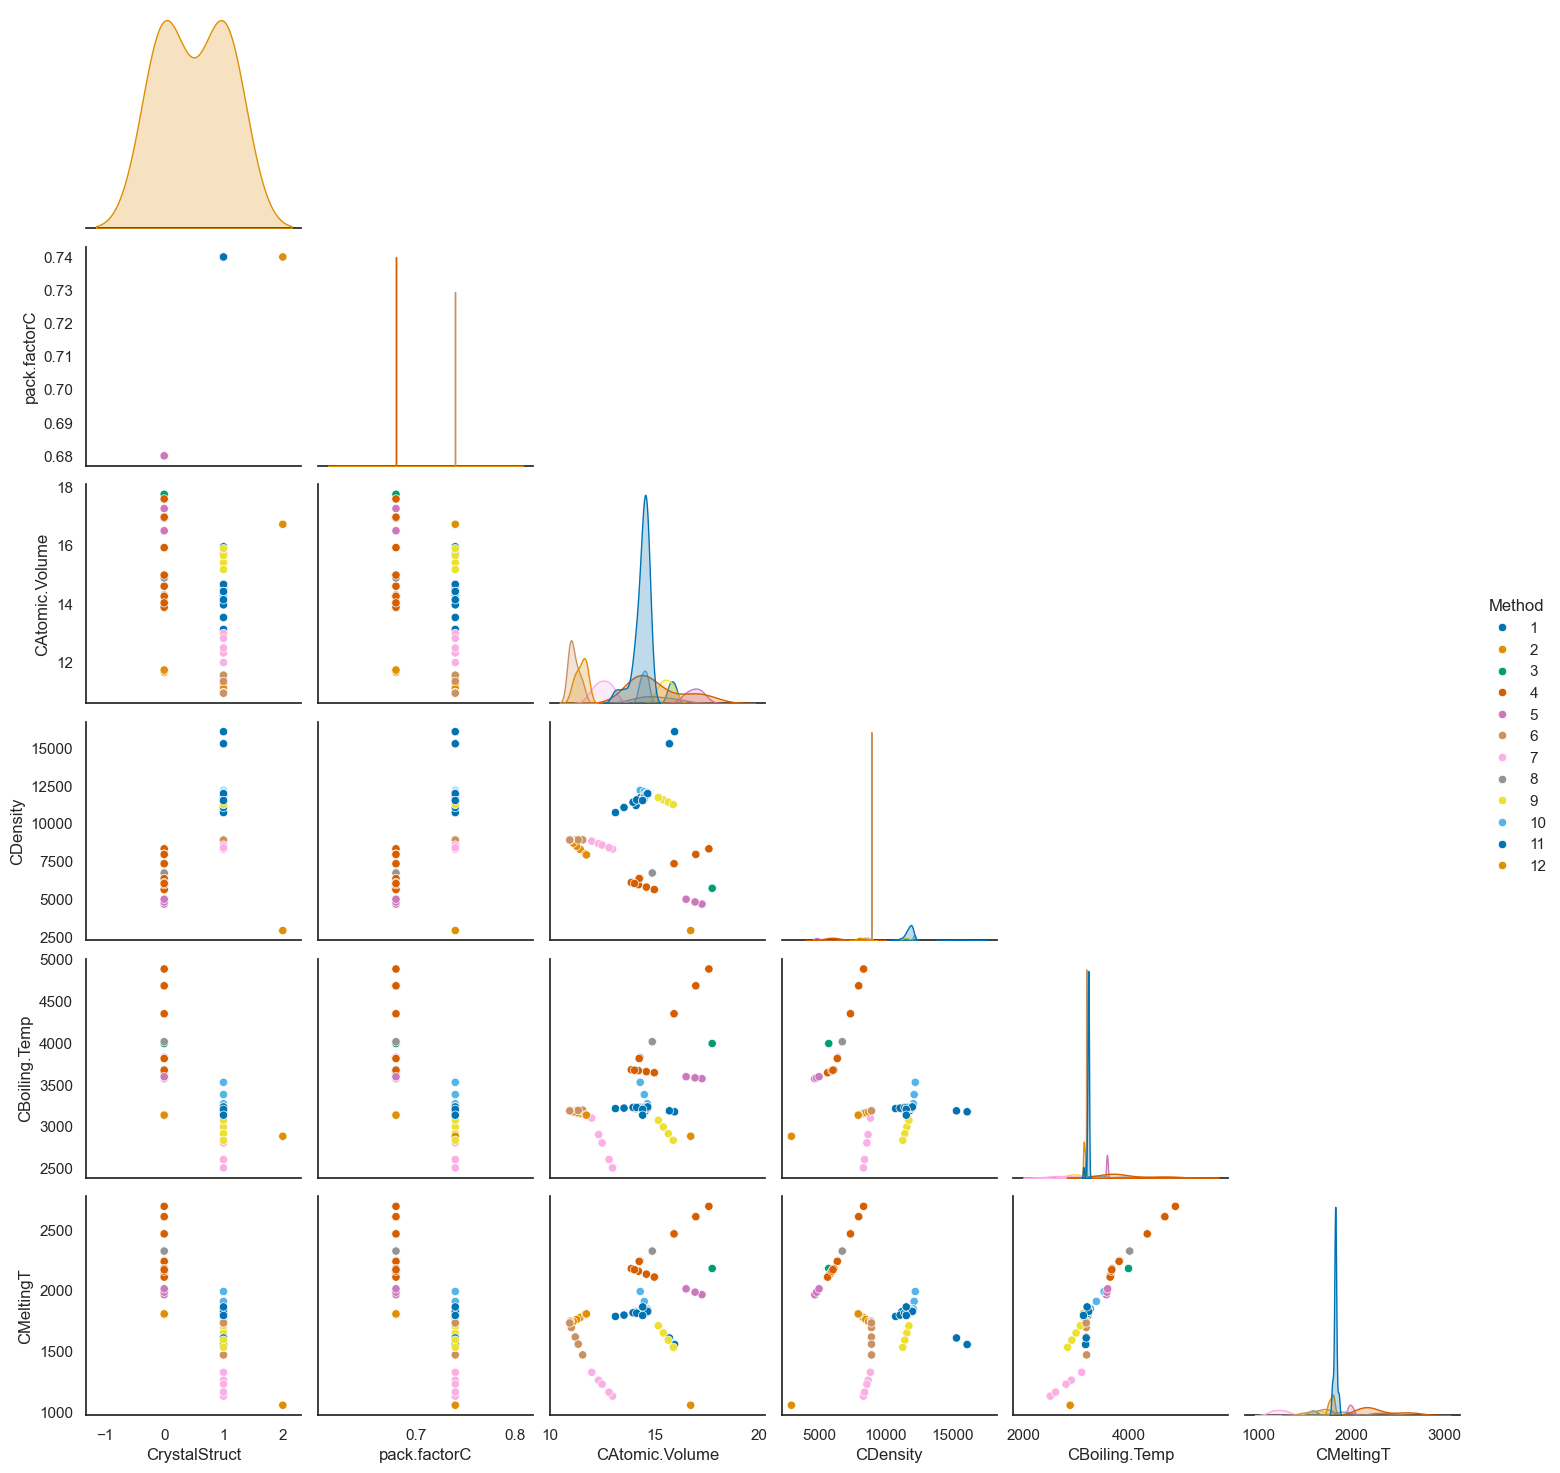

In [33]:
palette = sns.color_palette("colorblind", n_colors = len(data_cleaned["Method"].unique()))
opacity = 1.0
color = [(*color, opacity) for color in palette]

a = sns.pairplot(data_cleaned, x_vars = ["CrystalStruct", "pack.factorC", "CAtomic.Volume", "CDensity", "CBoiling.Temp", "CMeltingT"], y_vars = ["CrystalStruct", "pack.factorC", "CAtomic.Volume", "CDensity", "CBoiling.Temp", "CMeltingT"], hue = "Method", palette = color, corner = True)

plt.show()